$$ \Large{\textbf{DNA Sequence Classification: Machine Learning and Digital Signal Processing}} $$   
$$ \large{\textbf{Part I: Supervised Classification of Birds, Fishes, Mammals}} $$

$$ \small{\textbf{Dr. Stéphane DEDIEU, Fall 2022. }} $$

<h1 id="intro">Introduction</h1> <a class="anchor" id="chapter1"></a>


## Context  <a class="anchor" id="section_1_1"></a>
<br>
<span style="color:#4169E1">  In this project we develop effective methods for classifying genomes based on Digital Signal Processing, Machine Learning, Deep Learning. This is on-going research and results will be published on a regular basis. 
<br><br>    
As a starting point we analyzed the following paper [1], and references, due to the high effectiveness of their method: <code>ML-DSP</code>,  thoroughly detailed applications and the amount of results reported:  <br>
<br>
<span style="color:#4169E1"> <i><b> "ML-DSP: Machine Learning with Digital Signal Processing for ultrafast, accurate, and scalable genome classification at all taxonomic levels" </b></i> by Gurjit S. Randhawa , Kathleen A. Hill and Lila Kari.
Department of Computer Science, University of Western Ontario, London, ON, Canada.
<span style="color:#4169E1"> Randhawa et al. BMC Genomics (2019) 20:267
https://doi.org/10.1186/s12864-019-5571-y
<br>
<br>
If you are to use any of the research below, please cite the team at University of Western Ontario. <br> 
The team imported genomes from NCIB and built databases in various kingdoms, phylums, classes, genres: mammals, birds, fish, fungi, insects <b>.  mtDNA genomes </b>  <b> mitochondrial DNA </b>. (Abuse of terminology:  most of the time we will write "DNA sequences"). <br> 
<br>
    
## Objectives     
    
In this project, one of the objective is develop DSP methods that will further improve genome supervised classification accuracy, particularly with the most challenging datasets described in [1]: fungi, protists...   
<br>
At that point we develop basic pre-processing methods, based on our solid experience in Digital Signal Processing applied to audio or sensor signals. Actually we will treat DNA sequences as "sensors signals" in the time domain. <br>
<br>
<b>Part I, current notebook:</b> is dedicated to early development of our own approach,<code> ML-FFT </code>, which is the simplest method we can think of. It is successfully tested with the Bird-Fish-Mammal dataset and a 100 % accuracy with Logistic Regression or SVM. <b>But it fails with the Fungi dataset.</b> <br>
<br>
<b>Part II A</b> and <b>PartII B</b> are dedicated to the classification of Fungi DNA sequences. It is a small set, it was challenging and we had to introduce a simple alignment method based on cross-correlation to significantly outperform Gurjit S. Randhawa ML-DSP accuracy. 
<br>
<br>
Following Parts will be dedicated to other datasets: 
- Protists
- Insects
    
Dr. Randhawa et al performed quantitative comparisons with state-of-the-art classification software tools on two small benchmark datasets:
    
- 38 influenza viral genomes
- 41 mammals 
     
ML-DSP ouperforms alignment-based software MEGA7 (alignment with MUSCLE or CLUSTALW) in terms of processing time, while having comparable classification accuracies for small datasets and superior accuracies for the large dataset.
We have no accesss to these software but we will try to outperform ML-DSP results by Dr Gurjit S. Randhawa et al. 
<br>    
Eventually we will introduce more sophisticated pre-processing methods. And eventually train Deep Learning algorithms.   
<br>  
<b>Last remark:</b> this Jupyter Notebook is very detailed, since we intend to publish some methods and results in an article. You can directly access Results and Conclusions sections. They are presented before the Python code.

# Quick review of ML-DSP method

ML-DSP method by Dr. Gurjit S. Randhawa et al. 

##  Principle
    
<span style="color:#4169E1"> We reproduce here the paragraph in article [1] (in extenso): 
    
<span style="color:#4d6846"> The main idea behind ML-DSP is to combine supervised machine learning techniques with digital signal processing, for the purpose of DNA sequence classification. More precisely, for a given set $S={S_1,S_2,…,S_n}$ of $n$ DNA sequences, ML-DSP uses:
<span style="color:#4d6846">
- <span style="color:#4d6846"> DNA numerical representations to obtain a set $N={N_1,N_2,…,N_n}$ where $N_i$ is a discrete numerical representation of the sequence $S_i$, $1≤i≤n$.

- <span style="color:#4d6846"> Discrete Fourier Transform (DFT) applied to the length-normalized digital signals $N_i$, to obtain the frequency distribution; the magnitude spectrum $M_i$ of this frequency distribution is then obtained.

- <span style="color:#4d6846"> Pearson Correlation Coefficient (PCC) to compute the distance matrix of all pairwise distances for each pair of magnitude spectra $(M_i,M_j)$, where $1≤i,j≤n$.

- <span style="color:#4d6846">Supervised Machine Learning classifiers which take the pairwise distance matrix for a set of sequences, together with their respective taxonomic labels, in a training set, and output the taxonomic classification of a new DNA sequence. To measure the performance of such a classifier, we use the 10-fold cross-validation technique.

<span style="color:#4d6846"> Independently, Classical Multidimensional Scaling (MDS) takes the distance matrix as input and returns an (n×q) coordinate matrix, where n is the number of points (each point represents a unique sequence from set S) and q is the number of dimensions. The first three dimensions are used to display a MoDMap, which is the simultaneous visualization of all points in 3D-space.

<span style="color:#006699"> Lastly, their analysis shows that the “Purine/Pyrimidine”, “Just-A” and “Real” numerical representations of DNA sequences outperform ten other such numerical representations used in the Digital Signal Processing literature for DNA classification purposes.  

## Claims
    
    
<i>The computational efficiency of ML-DSP is due to the fact that it is alignment-free (hence it does not need multiple sequence alignment), while the combination of 1D numerical representations, Discrete Fourier Transform and Pearson Correlation Coefficient makes it extremely computationally time efficient, and thus scalable.  </i>  
    



# Our initial approach: ML-FFT


<br>
<br>
<span style="color:#4169E1"> 

There a few troubling aspects in the literature when dealing with DNA sequences with variable length, from about 16000 to 5000000. 
Different methods for length-normalizing digital signals were tested and are reported in the literature review of Gurjit S. Randhawa article [1]: down-sampling, up-sampling to the maximum length using zero padding, even scaling extension, periodic extension, symmetric padding, or anti-symmetric padding. 

Candid questions came to mind. For avoiding length-normalizing digital signals. <br>

#### Can we average FFT spectrums over the full length of DNA sequences?

Again, if we want to avoid length normalizing techniques, could the DNA sequence treated as a long time <i> audio signal</i>. In this case we would implement coherent averaging of FFT spectrum magnitude and phase, length= NFFT bins, without worrying about the variable length of DNA sequences.      
    
    
#### Can we work with short FFT?
 
Short here will mean NFFT= 256 to 2048 bins. Can a short time frame, NFFT bins long, could be sufficient to describe unique charateristics of a specie in a class or a phylum? And if we are to select a NFFT frame in a collection of DNA sequences, which would be the best criteria? We bring additional answers to this question in Part IIa.   
    
#### Can we directly feed FFT to the Machine Learning model?

Instead of working with a distance like the Pearson Correlation Coefficient, that significantly reduces the dimension of the classification problem, can we just use the FFT spectrum: magnitude, Phase as a feature for the Machine Learning model. We found that the FFT size had an impact, it the ML model was succesfull with NFFT=1024, NFFT=2048 but it did not work well with very long FFT.       
    
#### Is phase important ? 
  
A Fourier tranform will describe the content of various types of oscillations based on their wavelength. If the magnitude of the FFT spectrum describes the "distribution" of the power (actually sqrt of power) v. frequency, phase imforms about the relative "position" of trains of oscillations in the signal. This maybe important in indentifying the genome of a specific class or even specie.     

    
    
##  Methodology
<br>

<span style="color:#4169E1">
    
- import data
- turn data into PP (or JustA) numerical encoding. 
- define a virtual sampling frequency, fs. And listen to DNA sequences. For   
- Applying FFT to NFFT long frames
- Feed FFT magnitude (and phase sometimes) to Classification Algorithms: Logistic Regression, SVM. With optimization of hyperparameters and 10 folds cross validation. KNN, Decision Tree, can be implemented as an exercise.  
    


     
    
# ML-FFT: Results
  
    
<span style="color:#4169E1">  The dataset contains 3740 complete mtDNA genomes of VERTEBRATES in 3 classes: 553 bird genomes, 2313 fish genomes, and 874 mammalian genomes. Quantitatively, the best ML-DSP classification accuracy score 100% !  was achieved by the Quadratic SVM classifier. 

<span style="color:#4169E1"> Our simple method must at least reach the same level of accuracy. Using the same tray to each a similar level of accuracy with our method.  
    
<span style="color:#4169E1"> Data is split in training set, testing set, 0.8 - 0.2, with a shuffle option (the same for all algorithms tested) and a stratify options for keeping a similar proportion of labels in both sets. <br>
Like the authors, we optimize hyperparameters and use a 10 folds cross-validation. <br>  
Accuracy is measured with the test set.  

<span style="color:#4169E1"> AUTHORS analysis shows that <i> the “Purine/Pyrimidine”, “Just-A” and “Real” numerical representations of DNA sequences outperform ten other such numerical representations used in the Digital Signal Processing literature for DNA classification purposes. </i> We investigated JustA and “Purine/Pyrimidine” (P/P) numerical representations and got good resulats with both of them. In this this notebook, we use P/P but the code can easily be modified for testing other types of DNA sequence numerical encoding.     

<br>    
<span style="color:#4169E1">"NFFT frames" means "frames of length= NFFT points."
<br>

<span style="color:#4169E1"> It is not suitable for datasets of sequences of very different lengths (our study: fungi mtDNA genomes dataset - 1364 bp to 235,849 bp <br>
 - we will test short FFT NFFT=256 and longer NFFT=2048
 - windowing or preventing leakage and additional spectrum oscillations
 - filter b,a 
 - averaging with NFFT=256 and NFFT=2048 over the full sequence length
 - we will condisder the "frequency response", i.e. half the spectrum.  
 - we will retain the phase ! Since ML algorithms don't work with complex variables, we will split spectrum in Magnitude, Phase. 
 

| Approach                                 | Accuracy |      ML Technique         |
| ---                                      | ---      |   ---                     |
|First NFFT=  512 points                   |  97-98%  |       SVM  rbf kernel     | 
|First NFFT=  512 points                   |  97-98%  |       SVM  rbf kernel     | 
|First NFFT= 1024 Magnitude+Phase (1024 features) | <b> ~100% </b> |  SVM linear kernel     |
|First NFFT= 1024 Magnitude only (512 features) | <b> ~100% </b>   |    SVM  rbf kernel     |      
    
       
Selecting the first NFFT=256 points for computing the FFT, allows an accuracy of 97-98%
Selecting the first NFFT 2048 points for computing the FFT allows an accuracy >99%. 
Selecting average spectrum over the full length of   accuracy >99%. 
 

    
<span style="color:#4169E1"> Overall the phase is not necessary, except for low values of NFFT: 256, 512.  <br>
    
<span style="color:#4169E1"> Best results: FFT or first NFFT=1024 points of the DNA sequence, spectrum magnitude only (512 features) is shown below.      
    
     
<table border="1" width='750px'>
<tr>
    <td> <img src="SVM_Bird_Fish_Mammal_Classification.png" alt="Drawing" style="width: 450px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i>Classification accuracy</i> </figcaption> </td>
    <td> <img src="Bird_Fish_Mammal_SVM.png" style="width: 450px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i> Confusion Matrix </i> </figcaption>  </td>

</tr>
<tr style='text-align:center; vertical-align:middle'></tr> 
<table border="1" width='750px'>   
<tr>    
<figcaption style="text-align:center;color:black;font-size:14px;"> <b><i> Best ML-FFT results with SVM - Linear kernel  </i><b> </figcaption>
</tr>    
   

# Conclusions
<br>
<span style="color:#4169E1"> 

With a good knowledge of DSP principles, we can reach a high level of accuracy with the simple ML-FFT method:

- without aligning DNA sequences
- by selecting short DNA sequences NFFT=512 or NFFT=1024 points so that we don't have to scale all  
- filter, window the signal and compute FFT.
- apply ML models directly to the Magnitude (and the phase) of the FFT  

The ML-FFT method is a first introduction. It was sufficient for classifying Birds, Mammals, Fishes, but it failed to properly identify Basidiomycota (Fungi) in the present study.

In Part II, we add a preliminary alignement method based on cross-correlation after selecting a reference subsequence in a DNA sequence (Part IIa) and apply the ML-FFT method for classifying Fungi, after they were pre-classified (Part IIb).   

# Appendix

## Datasets  
    
<span style="color:#4169E1"> All datasets in this paper can be found at https://github.com/grandhawa/MLDSP in the “DataBase” directory. The mitochondrial dataset comprises all of the 7396 complete reference mtDNA sequences available in the NCBI Reference Sequence Database RefSeq on June 17, 2017. We performed computational experiments on several different subsets of this dataset. The bacteria dataset comprises all 4710 complete bacterial genomes with lengths between 20,000 bp and 500,000 bp, available in the aforementioned NCBI database on the same date. The dengue virus dataset contained all 4721 dengue virus genomes available in the NCBI database on August 10,2017. Note that any letters “N” in these DNA sequences were deleted.

<span style="color:#4169E1"> For the performance comparison between ML-DSP and other alignment-free and alignment-based methods we also used the benchmark datasets of 38 influenza virus sequences, and 41 mammalian complete mtDNA sequences from [47].
    
<span style="color:#4169E1"> Datasets are availble on Dr. Gurjit S. Randhawa Github following repositories:  

https://github.com/grandhawa/MLDSP/tree/master/DataBase/Birds-Fish-Mammals
    
https://github.com/grandhawa/MLDSP/tree/master/DataBase/Fungi
    
<span style="color:#4169E1"> Data was extracted from National Library of Medicine,  National Center for Biotechnology Information (NCBI) website. The database can be searched and genome of various live species, plants, fungi.  
    
https://www.ncbi.nlm.nih.gov/labs/gquery/all/?term=NC_001224.1    
 

##   References
<br>
<br>
<span style="color:#4169E1">

[1] "ML-DSP: Machine Learning with Digital Signal Processing for ultrafast, accurate, and scalable genome classification at all taxonomic levels" by Gurjit S. Randhawa , Kathleen A. Hill and Lila Kari. Department of Computer Science, University of Western Ontario, London, ON, Canada. Randhawa et al. BMC Genomics (2019) 20:267 https://doi.org/10.1186/s12864-019-5571-y

[2] "Genomic Signal Processing Methods for Computation of Alignment-Free Distances from DNA Sequences
Borrayo E, Mendizabal-Ruiz EG, Vélez-Pérez H, Romo-Vázquez R, Mendizabal AP, et al. (2014) Genomic Signal Processing Methods for Computation of Alignment-Free Distances from DNA Sequences. PLOS ONE 9(11): e110954. https://doi.org/10.1371/journal.pone.0110954

[3] Karel Sedlar, Helena Skutkova, Martin Vitek, Ivo Provaznik,Set of rules for genomic signal downsampling,
Computers in Biology and Medicine, Volume 69, 2016, Pages 308-314, ISSN 0010-4825,
https://doi.org/10.1016/j.compbiomed.2015.05.022.

[4] Changchuan Yin, Ying Chen, Stephen S.-T. Yau, A measure of DNA sequence similarity by Fourier Transform with applications on hierarchical clustering, Journal of Theoretical Biology, Volume 359, 2014, Pages 18-28, ISSN 0022-5193, https://doi.org/10.1016/j.jtbi.2014.05.043.


## Glossary

Taxonomic Ranks
from Wikipedia:   https://en.wikipedia.org/wiki/Taxonomic_rank

| Latin | English     |     French | 
| ---     |  ---      |  ---    |
|regio	  | domain                                    | empire, domaine   |         
| regnum  |	kingdom                                   | règne  |                   
| phylum  |	phylum (in zoology) / division (in botany)| embranchement, division |  
| classis |	class                                     | classe |
| ordo    |	order                                     | ordre  |
|familia  |	family                                    | famille | 
|genus	  |  genus                                    | genre  |
|species  |	 species                                  | espèce |

TCAG Nucleotides: DNA sequences Numerical representation (we say "numerical encoding"). From Table in [1]
<br>


|  | Type  | Encoding	| Output for S1 = CGAT|
| --- | --- | --- | --- |  
|1 |   Integer	| T=0, C=1, A=2, G=3 |	[ 1 3 2 0] |
|2	|Integer (other variant)| T=1, C=2, A=3, G=4 |	[ 2 4 3 1] |
|3	|Real |	T=−1.5, C=0.5, A=1.5, G=−0.5 |	[ 0.5 −0.5 1.5 −1.5] |
|4	|Atomic |	T=6, C=58, A=70, G=78 |	[ 58 78 70 6] |
|5	|EIIP (electron-ion interaction potential) |	T=0.1335, C=0.1340, A=0.1260, G=0.0806 |	[ 0.1340 0.8060 0.1260 0.1335] |
|6	|PP (purine/pyrimidine) |	T/C=1, A/G=−1 |	[ 1 −1 −1 1] |
|7	|Paired numeric	| T/A=1, C/G=−1	[ −1 −1 1 1] |
|8	|Nearest-neighbor based doublet	0−15 for all possible doublets| ..  |	[ 14 8 1 7] |
|9	|Codon	0−63 for all possible 64 Codons| ... |	[ 2 35 22 44]  |
|10	|Just-A	| A=1, rest=0 |	[ 0 0 1 0]  |
|11	|Just-C	| C=1, rest=0 |	[ 1 0 0 0]  |
|12	|Just-G	| G=1, rest=0 |	[ 0 1 0 0]  |
|13	|Just-T	| T=1, rest=0 |	[ 0 0 0 1]  |



##  Required libraries

In [1]:
#--------------------------------------------
# Notebook wide presentation
#--------------------------------------------
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

#-------  For centering figures 
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [2]:
#!pip install  screed

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [6]:
import string

In [7]:
import screed # A Python library for reading FASTA and FASQ file format.
def readFastaFile(inputfile):
    """
    Reads and returns file as FASTA format with special characters removed.
    """
    with screed.open(inputfile) as seqfile:
        for read in seqfile:
            seq = read.sequence
    return seq

In [8]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    #sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    sns.heatmap(cm, square=True, annot=True, annot_kws={'fontsize':16}, fmt="d", cmap='Blues', cbar=True)  # modified for cosmetic reasons. We want beauty. 
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 

    ax.xaxis.set_ticklabels(['Birds', 'Fishes', 'Mammals']);ax.yaxis.set_ticklabels(['Birds', 'Fishes', 'Mammals'])

<h1 id="dataset">DNA Sequences dataset and Numerical Encoding</h1>


## Importing datasets


<span style="color:#4169E1"> We must read FASTA/FASQ Files.  <br> We start with downloading all files in folders: Birds, Fish, Mammals. **Folders are stored locally.** 

In [9]:
import glob
import re
import os

bird_folder="MLDSP-master/DataBase/Birds-Fish-Mammals/Birds/"  
fish_folder="MLDSP-master/DataBase/Birds-Fish-Mammals/Fish/"  
mams_folder="MLDSP-master/DataBase/Birds-Fish-Mammals/Mammals/"  

bird_fnames = glob.glob(bird_folder+'B*.txt') # Will give a list of all files names # Warning: F1 F100  F101.... 
fish_fnames = glob.glob(fish_folder+'F*.txt')
mams_fnames = glob.glob(mams_folder+'M*.txt') # Will give a list of all files names # Warning: F1 F100  F101.... 

bird = []
fish=  []
mams=  []

for fname in bird_fnames:
    bird.append(readFastaFile(fname))
    
for fname in fish_fnames:
    fish.append(readFastaFile(fname))

for fname in mams_fnames:
    mams.append(readFastaFile(fname))

<span style="color:#4169E1"> We imported DNA sequence lists: bird, fish, mams coded with nucleotides TCAG. <br> The lengths of DNA sequences depend on species, even inside the same animal class.   


## Basic Insight in Dataset


<span style="color:#4169E1"> We quickly check a few dimensions and DNA sequences.  

In [10]:
print(np.shape(bird), np.shape(fish), np.shape(mams))
print(len(bird[0]))
print(len(bird[1]))
print(len(bird[2]))
print(len(bird[3]))
print(bird[1][0:10])

(553,) (2313,) (874,)
16714
17070
16698
16702
TAATTAAACG


<span style="color:#4169E1"> We imported DNA sequence lists: bird, fish, mams coded with nucleotides TCAG. <br> The lengths of DNA sequences depend on species, even inside the same animal class. 

## Numerical conversion of DNA sequences

<span style="color:#4169E1">  For applying Signal Processing procedures, we will code DNA sequences with numerical values.  <br> As stated by the authors, several coding schemes are possible. In Table <br>
    
    * Method 1:  TCAG--> 0,1,2,3
    * Method 2:  TCAG--> 1,2,3,4
    * Method 3:  TCAG--> -1.5, 0.5, 1.5, -0.5
    * Method 4:  TG---> 1, CA ---> -1    PP (Purine/Pyrimidine) encoding used in the reference article.
    * Method 5:  A ---> 1, TCG ---> 0    "Just A" method. 
    
    
<span style="color:#4169E1"> Since we will apply a FFT to the DNA sequences "signals", it is important to keep the signal symmetric relative to the horizontal axis. Otherwise we introduce a DC bias vertical shift) and the FTT spectrum magnitude will exhibit a very high amplitude at frequency = 0. We may implement a high-pass filter with a very low corner frequency. But the best method is still symmetrization. <br>   
**PP and "Just A" codings gave the best classification results.** <br> 
<span style="color:#4169E1"> With PP (-1,1), DNA sequences signals are naturally symmetric relative to the horizontal axis.<br> "just A" will be coded:   A= 0.5, TCG= -0.5. <br>      
We will not report about any other coding method.      

In [11]:
#----------
# At the moment and for validation purposes, we keep all conversion steps separated. 
#---------- 
def conversion_DNA_str(X,Y,instr, outstr):
        for j in range(0,len(X)):
            Y.append(X[j].translate({ord(x): y for (x, y) in zip(instr, outstr)}))        
        return Y
#----------    
def conversion_DNA_num(X,Y):
        for j in range(0,len(X)):
            Y.append([int(x) for x in str(X[j])])     
        return Y

In [12]:
#------------------
#  Testing various types of numerical representations. 
#------------------
instr = "TCAG"
#outstr = "0010" ; cornr= 0.5   #  Just A representation. Substract 0.5 for symmetrisation of signal relative to x-axis. 
#outstr = "1234" ; cornr=-5/2   #  Integer representation I. Not tested
#outstr = "0123" ; cornr=-3/2   #  Integer representation II. Not tested
outstr = "2200"  ; cornr= 1    #  PP representation  [T,C]= 1, [A,G]= -1  Must substract 1 in all DNA sequences matrices  ! 

DNA_B=[]
DNA_M=[]
DNA_F=[]
#---------
DNA_B=conversion_DNA_str(bird, DNA_B,instr, outstr)
DNA_M=conversion_DNA_str(fish, DNA_M,instr, outstr)
DNA_F=conversion_DNA_str(mams, DNA_F,instr, outstr)
#--------- 
B=[]
F=[]
M=[]

B=conversion_DNA_num(DNA_B,B)
M=conversion_DNA_num(DNA_M,M)
F=conversion_DNA_num(DNA_F,F)

<span style="color:#4169E1"> Conversion List ---> Matrix (2D np.array)

In [13]:
# DNA sequences matrices 
Mat_DNA_B = np.array([np.array(x) for x in B], dtype=object) - cornr
Mat_DNA_F = np.array([np.array(x) for x in F], dtype=object) - cornr
Mat_DNA_M = np.array([np.array(x) for x in M], dtype=object) - cornr

<span style="color:#4169E1"> We plot the first 100 nucleotides for the DNA sequences of the Canadian Goose and the European Beaver. With PP coding, we find results similar to the article in Figure .  

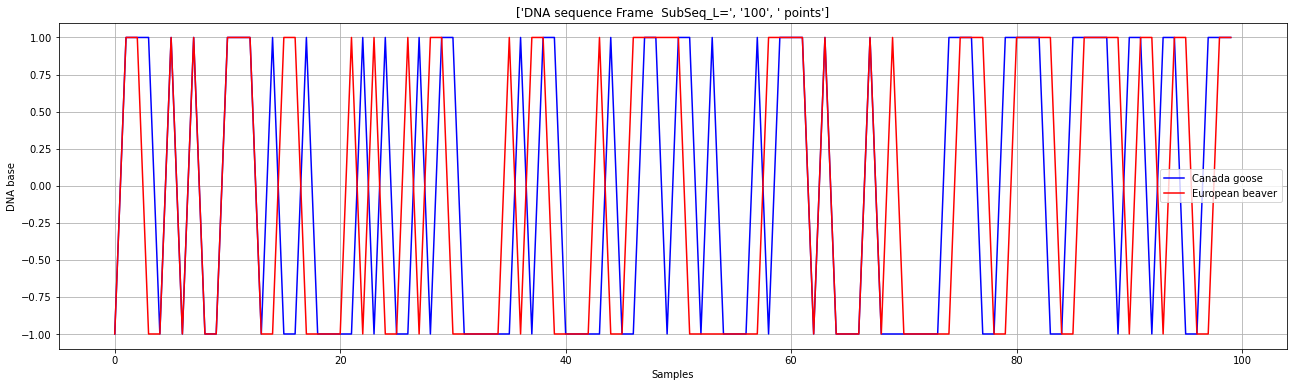

In [14]:
SubSeq_L=128
SubSeq_L=100   # Length of sub-sequence 
plt.figure(figsize=(22, 6))
plt.plot(Mat_DNA_B[32][0:SubSeq_L],color='b')  # single slice
plt.plot(Mat_DNA_M[826][0:SubSeq_L],color='r')  # single slice
plt.xlabel("Samples")
plt.ylabel("DNA base")
plt.title(["DNA sequence Frame  SubSeq_L=", str(SubSeq_L)," points"])
plt.legend(['Canada goose', 'European beaver'])
plt.grid()
plt.show()

## Analysis - Nucleotides count

<span style="color:#4169E1"> We count the number of "1" and "-1" in each DNA sequence for each animal class: Fish, Bird, Mammals

In [15]:
count_DNA_B_x= np.empty(len(Mat_DNA_B))
count_DNA_B_y= np.empty(len(Mat_DNA_B))
count_DNA_F_x= np.empty(len(Mat_DNA_F))
count_DNA_F_y= np.empty(len(Mat_DNA_F))
count_DNA_M_x= np.empty(len(Mat_DNA_M))
count_DNA_M_y= np.empty(len(Mat_DNA_M))

for j in range(0,len(Mat_DNA_B)):
     count_DNA_B_x[j] =   np.count_nonzero(Mat_DNA_B[j] == 1)
     count_DNA_B_y[j] = len(Mat_DNA_B[j]) - count_DNA_B_x[j]
    
for j in range(0,len(Mat_DNA_F)):
     count_DNA_F_x[j] =   np.count_nonzero(Mat_DNA_F[j] == 1)
     count_DNA_F_y[j] = len(Mat_DNA_F[j]) - count_DNA_F_x[j]

        
for j in range(0,len(Mat_DNA_M)):
     count_DNA_M_x[j] =   np.count_nonzero(Mat_DNA_M[j] == 1)
     count_DNA_M_y[j] = len(Mat_DNA_M[j]) - count_DNA_M_x[j]

#count_DNA_B_x[0:10], count_DNA_B_y[0:10]  

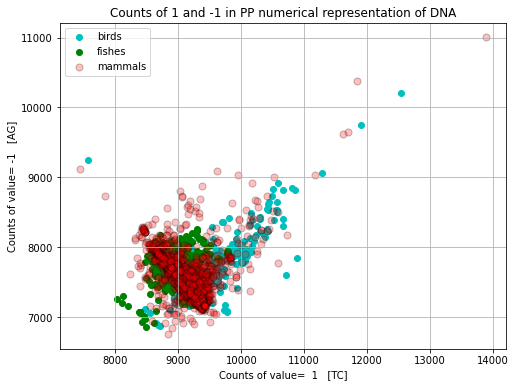

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(count_DNA_B_x, count_DNA_B_y, c="c")
plt.scatter(count_DNA_F_x, count_DNA_F_y, c="g")
plt.scatter(count_DNA_M_x, count_DNA_M_y, s=50, c="r", alpha=0.25, edgecolors="k")
plt.legend(['birds', 'fishes', 'mammals'])
#----------------------------------------
plt.title("Counts of 1 and -1 in PP numerical representation of DNA") 
plt.xlabel("Counts of value=  1   [TC]") 
plt.ylabel("Counts of value= -1   [AG]")
plt.grid(b=True, which='minor', color='grey', linestyle='--')
plt.grid()
plt.show()

<span style="color:#4169E1"> Comments: 3 separate groups although fishes and mammals seem to share similar count numbers. Count could be an information added to FFTs for helping with clusterization or supervised classification.  

In [17]:
print("Length of Birds 1st DNA sequence: ",  len(Mat_DNA_B[0]), " |||  Length of Birds 2nd DNA sequence: ", len(Mat_DNA_B[1]))

Length of Birds 1st DNA sequence:  16714  |||  Length of Birds 2nd DNA sequence:  17070


In [18]:
print("Number of DNA sequences:, Bird: ", Mat_DNA_B.shape, " Fishes: ", Mat_DNA_F.shape," Mammals: " , Mat_DNA_M.shape) 

Number of DNA sequences:, Bird:  (553,)  Fishes:  (874,)  Mammals:  (2313,)


## "Listening" to the DNA sequences.


<span style="color:#4169E1">  We can assume a frequency sampling <code>fs</code>. It will not impact the "shape" of spectrums, only the x-axis scale when computing FFT spectrums.<br>
In terms of "audio" all DNA sequence time signal amplitude: -1,1 reach 0 dBFS, which is maximum digital volume. We reduce the amplitude (-12 dB, x0.25) on safety concerns, if people listen with headsets. 

In [19]:
import sounddevice as sd

fs = 8000    
data = 0.25*np.concatenate( (Mat_DNA_B[32], Mat_DNA_B[32], Mat_DNA_B[32],Mat_DNA_B[32]))     # -12 dB 
data = 0.25*np.concatenate( (Mat_DNA_M[826], Mat_DNA_M[826], Mat_DNA_M[826],Mat_DNA_M[826]))     # -12 dB 

np.shape(data)
sd.play(data, fs)

<span style="color:#4169E1"> In both cases, bird= canadian goose(Mat_DNA_B[32]), mammal= European beaver(Mat_DNA_M[826]), there is a similar dominant wideband noise, sounding like "white noise". <br>
If we listen carefully, we will hear low to medium range frequency "beatings", "fluctuations", that are different. 
Assuming a sampling frequency fs, instead of a high definition of the "white noise" spectrum with large NFFT values, say NFFT=16 we may be able to capture beatings, fluctuations spectrum with a way lower value of NFFT.  <br> 

<span style="color:#4169E1"> At the end of this section we have 553 bird DNA sequences,  (553,)  Fishes:  (874,)  Mammals:  (2313,). <br>
We will not compute maximum length DFT or FFT, therefore we will not normalise their length. <br>
<br>
After computing all spectrums, we will be left with 553  spectrums all similar in length: NFFT//2 where NFFT is small compared with maximum DNA sequence length.  
<span style="color:#4169E1"> We now have Bird, Fish, Mammal arrays with different numbers of rows (number of DNA sequences). And also different number of columns (length of each DNA sequence)
Since we compute the FFT of each DNA sequence, we don't need to make all DNA sequnces the same length. <br>
Eventually, all FFT of all DNA sequences will have the same length (NFFT) and will be stored in a dataframe. 

# DNA SEQUENCES FFT

##  FFT Function Parameters

<span style="color:#4169E1"> 
    
<span style="color:#4169E1">         - NFFT: number of FFT bins <br>
        - SubSeq_L:   length of DNA subsequence used for computing the FFT <br>
        - st:         step (overlap) for averaging FFT on long DNA subsequences: SubSeq_L>NFFT <br>

<span style="color:#4169E1"> For preventing leakage and induced "short oscillations" in the spectrum, we apply a window on each frame: In general Hann or Blackman work well. <br> win=np.ones(NFFT + 1)[:-1]  means no windowing. 
    
<span style="color:#4169E1">  (1) If SubSeq_L >> NFFT, it means that we are sliding a NFFT window over the DNA sub-sequence of length SubSeq_L , and averaging each spectrum. <br>
(2) if SubSeq_L = NFFT we are computing the spectrum on first NFFT points. <br>
(3) step st= NFFT//2, NFFT//4, ...  defines the overlap when averaging spectrums. If SubSeq_L = NFFT, st= NFFT (no average, no overlapping).   
    
<span style="color:#4169E1"> The following function will return the "frequency response" of each DNA sequence i.e. half the complex spectrum (one-sided spectrum, length: NFFT//2 points). <br>
Classification algorithms will handle real values: magnitude AND phase of the frequency response. (NFFT values) 

In [20]:
from scipy import signal
from skimage import util
import scipy.signal

# Fonction FFT spectrum. Includes [b,a] signal filter in the "time" domain. 
def FFT_spectrum_ba(Mat_DNA, NFFT, SubSeq_L, st, win,b,a) :  #, spec_filter):
    spectrum_F= np.empty([len(Mat_DNA),  NFFT//2]).astype(complex)  
    for j in range(0,len(Mat_DNA)):  
        # AVERAGING on SubSequence length SubSeq_L
        frames = util.view_as_windows(Mat_DNA[j][0:SubSeq_L], window_shape=(NFFT,), step=st)
        # AVERAGING on full length DNA sequences
        #frames = util.view_as_windows(Mat_DNA[j], window_shape=(NFFT,), step=st)
        frames_win=scipy.signal.filtfilt(b, a,frames*win) #  WINDOWING
        spectrum_cplx  = np.fft.fft(frames_win)   # DOUBLE SIDED spectrum !!   
        # Average all frames FFT
        spectrum_F[j][:]= np.mean(spectrum_cplx, axis=0)[0:NFFT//2]  #  AVERAGING if SubSeq_L>NFFT
    return spectrum_F

In [22]:
# Parameters
#-------------------------------------------------------------
#NFFT = 256  # number of FFT bins
#NFFT = 512  # number of FFT bins
NFFT = 2048  # number of FFT bins
#----------------Subsequence Length ---------------------------
SubSeq_L= NFFT      # length of DNA subsequence 
#SubSeq_L= 1e8      # Averaging on full DNA sequence 
st=NFFT
#st=NFFT//8            # step for overlap.  st= NFFT if SubSeq_L= NFFT 
#---------- Windows -------------------------
win = np.hanning(NFFT + 1)[:-1]       # window for each frame
#win = np.blackman(NFFT + 1)[:-1]      # window for each frame
#win=np.ones(NFFT + 1)[:-1]  # No window

<span style="color:#4169E1"> <b> High pass filtering </b>
    
<span style="color:#4169E1">  A DC offset would result in a spectrum very high magnitude at frequency=0.
The P/P numerical representation results in a signal symmetric to the x-axis, without DC offset.  In spite of this, we found that the magnitude at frequency=0 was too high, and would flatten the rest of the spectrum after scaling/normalization. We implement a high pas filter with a very low corner frequency.   
     

<span style="color:#4169E1">   Building a IIR high-pass filter 

In [25]:
#import math   
#----
xx= np.arange(0, NFFT//2, 1, dtype=int)
xx=xx*fs/NFFT
print(len(xx))
print(xx[0:10])

1024
[ 0.       3.90625  7.8125  11.71875 15.625   19.53125 23.4375  27.34375
 31.25    35.15625]


<span style="color:#4169E1">  For stability purposes, the corner frequency will be defined by the fourth bin frequency (depends on fs define earlier). 

1024 <class 'numpy.ndarray'>


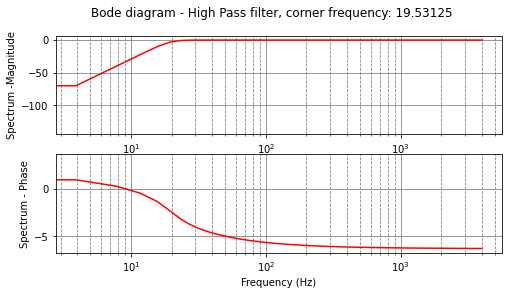

In [26]:
order=5
normal_cutoff=5*fs/NFFT
#----
b, a = signal.butter(order, normal_cutoff, btype='highpass', analog=False, output='ba', fs=fs)
wbutt, hbutt = signal.freqz(b, a,  worN=len(xx),fs=fs)
#----
print(len(wbutt), type(hbutt))
fig, axs = plt.subplots(2, figsize=(8,4))
fig.suptitle("Bode diagram - High Pass filter, corner frequency: "+ str(normal_cutoff) )
axs[0].semilogx(xx,20*np.log10(abs(hbutt[0:NFFT//2])),color='r')
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid(b=True, which='major', color='grey', linestyle='-')
axs[0].grid(b=True, which='minor', color='grey', linestyle='--')
#------------------------------------------------------------

axs[1].semilogx(xx,np.unwrap(np.angle(hbutt[0:NFFT//2])),color='r')
axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Spectrum - Phase")
axs[1].grid(b=True, which='major', color='grey', linestyle='-')
axs[1].grid(b=True, which='minor', color='grey', linestyle='--')

<span style="color:#4169E1"> For a double sided filter, we apply the filter to all signals in the time domain, with coefficients <b><i>b,a </i></b>.   

In [27]:
#---  Frequency response (one-sided spectrum)
spectrum_B= FFT_spectrum_ba(Mat_DNA_B, NFFT, SubSeq_L, st, win, b, a)  #, spec_filter)
spectrum_F= FFT_spectrum_ba(Mat_DNA_F, NFFT, SubSeq_L, st, win, b, a)  #, spec_filter)
spectrum_M= FFT_spectrum_ba(Mat_DNA_M, NFFT, SubSeq_L, st, win, b, a)  #, spec_filter)

In [28]:
print(type(spectrum_B), spectrum_B.shape)
print(type(spectrum_F), spectrum_F.shape)
print(type(spectrum_M), spectrum_M.shape)

<class 'numpy.ndarray'> (553, 1024)
<class 'numpy.ndarray'> (874, 1024)
<class 'numpy.ndarray'> (2313, 1024)


<span style="color:#4169E1">  We now have 3 one-sided spectrums complex matrices with NFFT//2 columns (frequency responses). <br> We can extract spectrums magnitude and phase and append all of them into a dataframe or a "features" matrix. <br> We will add a "Class" column, for example Class=0: Fish, 1: Birds, 2: Mammals. Column "Class" will serve as label in a supervised classification problem. 

## DNA spectrum examples

##### We plot half spectrums, aka "frequency response".  FISHES only  

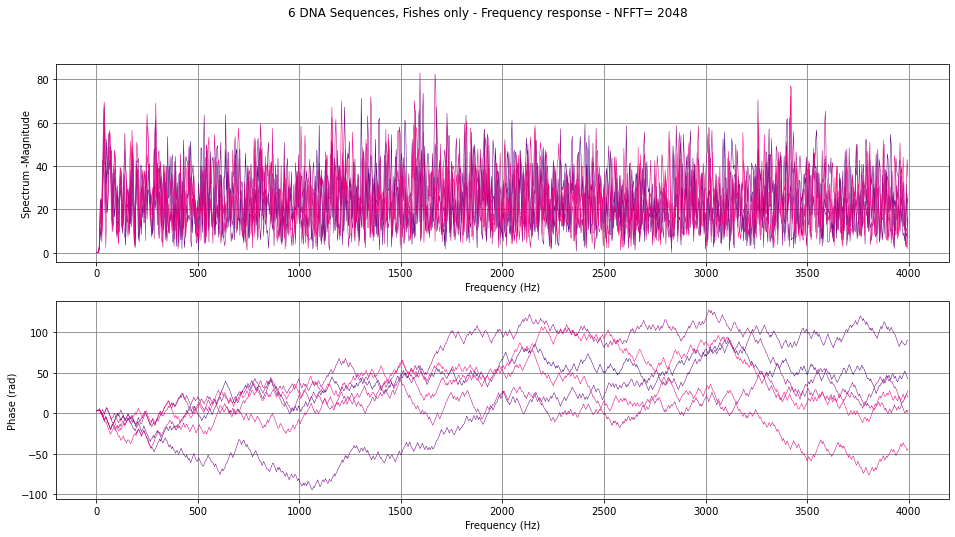

In [29]:
fig, axs = plt.subplots(2, figsize=(16,8))
fig.suptitle("6 DNA Sequences, Fishes only - Frequency response - NFFT= "+str(NFFT))
#  FFT Magnitude - HIGH-Pass 

for j in range(2,8) :
        #  FFT magnitude
        #axs[0].plot(xx,np.abs(spectrum_F[j]),color=((8-j)/8, 0.2, j/8), linewidth=0.5)
        axs[0].plot(xx,np.abs(spectrum_F[j]),color=(j/7, 0., 0.5), linewidth=0.5)
        #  FFT phase
        axs[1].plot(xx,np.unwrap(np.angle(spectrum_F[j])),color=(j/7, 0, 0.5), linewidth=0.5)

#--------------------------
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid(b=True, which='major', color='grey', linestyle='-')
axs[0].grid(b=True, which='minor', color='grey', linestyle='--')
#-----------------------------------------------------------------
axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Phase (rad)")
#axs[1].legend(['FFT', 'FFT w. window'])
axs[1].grid(b=True, which='major', color='grey', linestyle='-')
axs[1].grid(b=True, which='minor', color='grey', linestyle='--')
plt.show()

<span style="color:#4169E1"> With NNFT=2048, we observe: <br>
-"white noise" component we heard when listening to the sequences.  <br>
-peaks at some frequencies, that may point to interesting features: trains of nucleotides, that may characterise species, and maybe genre.  <br>
We recommend the reader to go back to the parameter section and test NFFT= 256, 512, 1024. <br>
Other techniques like spectrograms, wavelets may bring a plus in terms of feature extraction. This will be the object of future investigation.  <br>
<span style="color:#4169E1"> In terms of phase: we can't really find a similar trend except for 5 sequences under $1500 Hz$ for $f_s=8000 Hz$.  <br> Note that the slope of the phase is the group delay.
    

##### We plot one-sided spectrums, aka "frequency response".  First FISH, BIRD, MAMMAL on each list.   

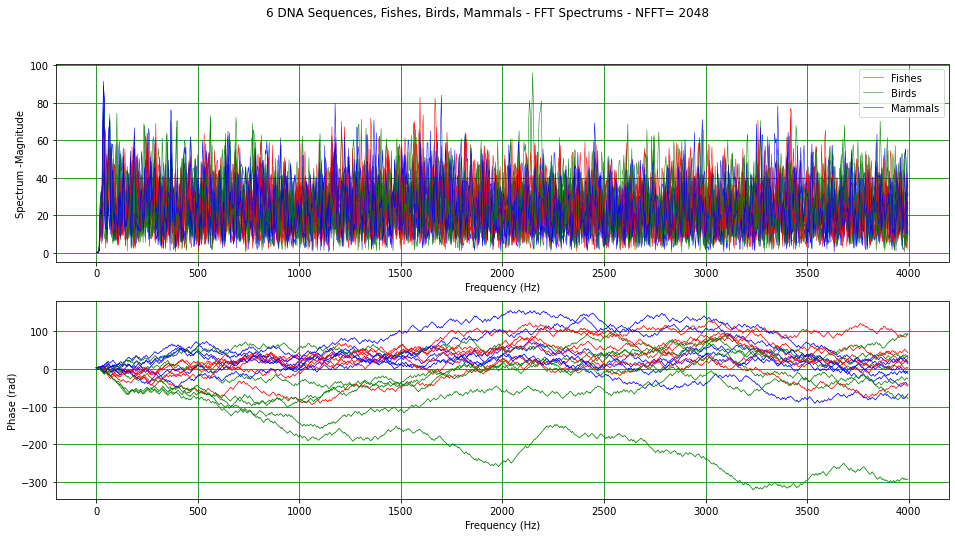

In [30]:
fig, axs = plt.subplots(2, figsize=(16,8))
fig.suptitle("6 DNA Sequences, Fishes, Birds, Mammals - FFT Spectrums - NFFT= "+str(NFFT))
# FFT magnitude

for j in range(2,8) :
#--------------------------    
#  FFT Spectrum magnitude
#--------------------------
    axs[0].plot(xx,np.abs(spectrum_F[j]),color='r', linewidth=0.5)
    axs[0].plot(xx,np.abs(spectrum_B[j]),color='g', linewidth=0.5)
    axs[0].plot(xx,np.abs(spectrum_M[j]),color='b', linewidth=0.5)
#-----------------------------
#  FFT Spectrum unwrap phase
#-----------------------------
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_F[j])),color='r', linewidth=0.75)
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_B[j])),color='g', linewidth=0.75)
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_M[j])),color='b', linewidth=0.75)
#--------------------------
axs[0].legend(['Fishes', 'Birds', 'Mammals'])
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid(b=True, which='major', color='g', linestyle='-')
axs[0].grid(b=True, which='minor', color='g', linestyle='--')

axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Phase (rad)")
#axs[1].legend(['FFT', 'FFT w. window'])
axs[1].grid(b=True, which='major', color='g', linestyle='-')
axs[1].grid(b=True, which='minor', color='g', linestyle='--')
#plt.show()

#  CLASSIFICATION

##   Dataframe, Labels, Features. 

Convert Spectrum to pandas dataframe 

In [31]:
spectrum_B_Mag=np.abs(spectrum_B)
spectrum_F_Mag=np.abs(spectrum_F)
spectrum_M_Mag=np.abs(spectrum_M)

In [32]:
spectrum_B_Phas=np.unwrap(np.angle(spectrum_B))
spectrum_F_Phas=np.unwrap(np.angle(spectrum_F))
spectrum_M_Phas=np.unwrap(np.angle(spectrum_M))

We now concatenate magnitude and phases arrays.  

In [33]:
spec_B=np.append(spectrum_B_Mag, spectrum_B_Phas, axis=1)
spec_F=np.append(spectrum_F_Mag, spectrum_F_Phas, axis=1)
spec_M=np.append(spectrum_M_Mag, spectrum_M_Phas, axis=1)

In [34]:
spec_B.shape, spec_F.shape, spec_M.shape

((553, 2048), (874, 2048), (2313, 2048))

In [35]:
df_B = pd.DataFrame(spec_B)
df_F = pd.DataFrame(spec_F)
df_M = pd.DataFrame(spec_M)

For each dataframe we append a new column "class"  B=0  F=1  M=3 

In [36]:
#classB= np.arange(0,len(df_B), 1, dtype=int)
listB =  [0] * len(df_B)
listF =  [1] * len(df_F)
listM =  [2] * len(df_M)

df_B['Class'] = listB
df_F['Class'] = listF
df_M['Class'] = listM

We create a large DATAFRAME   spectrum  

In [37]:
df_BFM= pd.concat([df_B,  df_F, df_M],axis=0)
df_BFM.shape

(3740, 2049)

In [38]:
df_BFM.head()

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Class
0,0.257139,0.265771,0.292332,0.348658,4.759729,23.582607,19.497532,9.266905,37.991806,75.573559,...,34.912797,32.538887,30.385900,33.387658,34.272310,37.233524,39.274944,41.774926,43.926934,0
1,0.266428,0.273763,0.291056,0.127525,4.251746,12.371684,20.447878,48.221886,48.551882,21.948066,...,-94.805082,-97.377387,-94.951295,-92.446399,-92.909973,-90.244451,-88.011518,-85.696272,-82.699397,0
2,0.168193,0.184667,0.232520,0.377162,1.238708,19.014525,32.737353,29.044867,27.372383,25.417619,...,32.949946,34.431380,31.816999,30.810235,28.030575,31.071048,34.189565,31.564617,30.588455,0
3,0.172409,0.193689,0.256492,0.325768,2.756039,20.443233,22.859857,15.598789,10.530518,17.413110,...,86.020661,84.485113,87.394006,89.967443,91.692695,94.369323,91.358061,90.865825,93.944839,0
4,0.035623,0.084142,0.186529,0.953315,9.567762,27.231411,15.854911,27.799289,7.937273,19.384983,...,-290.951098,-287.929526,-289.801321,-292.814086,-289.871460,-292.174952,-293.910452,-291.046039,-291.796341,0


In [39]:
Y = df_BFM['Class'].to_numpy()
Y[0:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [40]:
col_i= np.arange(0,NFFT, 1, dtype=int)
list_col_i= col_i.tolist()
df1 = df_BFM[list_col_i]
X0=df1.to_numpy()

In [41]:
X0.shape

(3740, 2048)

In [42]:
transform = preprocessing.StandardScaler()

In [43]:
X = transform.fit_transform(X0)

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=5,  stratify= Y)

In [45]:
Y_train[0:20]

array([1, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2],
      dtype=int64)

In [46]:
print( X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(2992, 2048) (748, 2048) (2992,) (748,)


## <span style="color:#0094cf;"> Logistic Regression </span>

In [47]:
#parameters ={"C":[0.01,0.1,1,5],'penalty':['l2'], 'solver':('newton-cg', 'lbfgs', 'liblinear')}# l1 lasso l2 ridge
parameters ={"C":[0.01,0.1,1,5],'penalty':['l2'], 'solver':['newton-cg']}# l1 lasso l2 ridge
#----------
lr=LogisticRegression(max_iter=1500)
print(parameters)

{'C': [0.01, 0.1, 1, 5], 'penalty': ['l2'], 'solver': ['newton-cg']}


In [48]:
logreg_cv=GridSearchCV(estimator=lr, param_grid=parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(max_iter=1500),
             param_grid={'C': [0.01, 0.1, 1, 5], 'penalty': ['l2'],
                         'solver': ['newton-cg']})

In [49]:
print("Best parameter:",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

Best parameter: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
accuracy : 0.9933132664437012


In [50]:
acc_LR=logreg_cv.score(X_test, Y_test);
print('Accuracy:', acc_LR)

Accuracy: 0.9946524064171123


In [51]:
yhat_LR= logreg_cv.predict(X_test)
print (classification_report(Y_test, yhat_LR, target_names=['Speech', 'Fishes','Mammals'])  )

              precision    recall  f1-score   support

       Birds       1.00      0.98      0.99       110
      Fishes       0.99      0.99      0.99       175
     Mammals       1.00      1.00      1.00       463

    accuracy                           0.99       748
   macro avg       0.99      0.99      0.99       748
weighted avg       0.99      0.99      0.99       748



In [52]:
yhat_LR=logreg_cv.predict(X_test)

Text(0.5, 1.0, 'Logistic Regression - Confusion matrix')

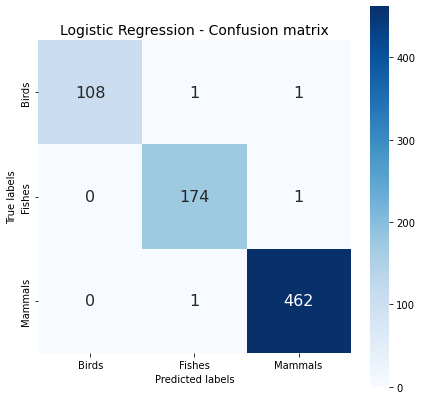

In [53]:
fig=plt.figure(figsize=(7,7))
plot_confusion_matrix(Y_test,yhat_LR)
plt.title("Logistic Regression - Confusion matrix", fontsize=14)
#plt.savefig("LOG_REG_Fungi_figure1.png")

## <span style="color:#0094cf;"> Support Vector Machine </span>

In [54]:
#parameters = {'kernel':['rbf'],
parameters = {'kernel':('linear','poly','rbf'),        
              'C': np.logspace(-3, 2, 5),
              #'gamma':np.logspace(-3, 1, 6)}
              'gamma':[0.001]}
svm = SVC()
print(parameters)

{'kernel': ('linear', 'poly', 'rbf'), 'C': array([1.00000000e-03, 1.77827941e-02, 3.16227766e-01, 5.62341325e+00,
       1.00000000e+02]), 'gamma': [0.001]}


In [55]:
svm_cv = GridSearchCV(svm,parameters,cv=10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 1.77827941e-02, 3.16227766e-01, 5.62341325e+00,
       1.00000000e+02]),
                         'gamma': [0.001],
                         'kernel': ('linear', 'poly', 'rbf')})

In [56]:
print("tuned hyperparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.01778279410038923, 'gamma': 0.001, 'kernel': 'linear'}
accuracy : 0.9936465997770345


In [57]:
acc_svm=svm_cv.score(X_test, Y_test)
print('Accuracy:', acc_svm)

Accuracy: 0.9973262032085561


In [58]:
yhat_svm= svm_cv.predict(X_test)
print (classification_report(Y_test, yhat_svm, target_names=['Birds', 'Fishes','Mammals'])) 

              precision    recall  f1-score   support

       Birds       1.00      0.98      0.99       110
      Fishes       0.99      1.00      1.00       175
     Mammals       1.00      1.00      1.00       463

    accuracy                           1.00       748
   macro avg       1.00      0.99      1.00       748
weighted avg       1.00      1.00      1.00       748



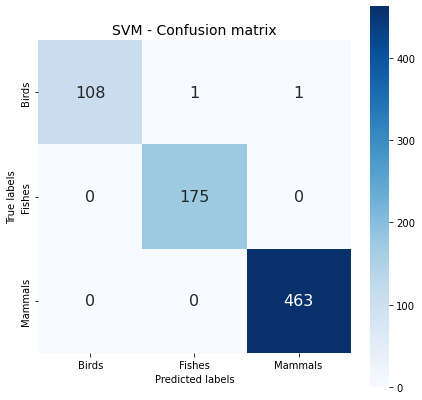

In [59]:
fig=plt.figure(figsize=(7,7))
plot_confusion_matrix(Y_test,yhat_svm)
plt.title("SVM - Confusion matrix", fontsize=14)
plt.savefig("BFM_figure2.png")